# Supervised Models

## Imported Libraries

In [1]:
!pip install xgboost==3.2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 27.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [11]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score
from brfss_utils import rename_cols

## Data Loading

In [31]:
# Load brfss dataset and make a copy

data_path = '/work/model_myocardial_infarction/dataset/processed_data.csv'
df = pd.read_csv(data_path)
df_cpy = df.copy()

## Data Structure and Sanity Check

In [ ]:
# Top 5 observations
df.head()

In [15]:
# Bottom 5 observations

df.tail()

,PHYSHLTH,MENTHLTH,POORHLTH,PERSDOC3,MEDCOST1,CHECKUP1,CVDSTRK3,CHCSCNC1,CHCOCNC1,CHCCOPD3,...,_EDUCAG,_INCOMG1,_SMOKER3,_CURECI3,_LCSYSMK,_LCSYQTS,DRNKANY6,_RFBING6,_DRNKWK3,_RFDRHV9
457665,NaN,2.0,NaN,1.0,1.0,3.0,0.0,0.0,0.0,0.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
457666,5.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,1.0,4.0,1.0,1.0,50.0,NaN,1.0,NaN,3.500000e+03,0.0
457667,0.0,0.0,NaN,2.0,0.0,3.0,0.0,0.0,0.0,0.0,...,4.0,5.0,4.0,1.0,NaN,NaN,1.0,1.0,1.400000e+02,1.0
457668,0.0,0.0,NaN,2.0,0.0,2.0,0.0,0.0,0.0,0.0,...,3.0,6.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
457669,30.0,0.0,30.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,3.0,4.0,1.0,NaN,NaN,0.0,1.0,5.397605e-79,1.0


In [17]:
# Number of observations and columns in the dataframe

df.shape

(457670, 73)

In [19]:
# Dataframe columns

df.columns

Index(['PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1',
       'CVDSTRK3', 'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2',
       'HAVARTH4', 'DIABETE4', 'MARITAL', 'VETERAN3', 'PREGNANT', 'DEAF',
       'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'USENOW3',
       'LCSFIRST', 'LCSNUMCG', 'AVEDRNK4', 'MAXDRNKS', 'FLUSHOT7', 'PNEUVAC4',
       'PREDIAB2', 'DIABTYPE', 'INSULIN1', 'FEETSORE', 'CIMEMLO1', 'CDSOCIA1',
       'ACEDEPRS', 'ACEDRINK', 'ACEDRUGS', 'ACEPRISN', 'ACEDIVRC', 'ACEPUNCH',
       'ACEHURT1', 'ACEADSAF', 'LSATISFY', 'SDLONELY', 'SDHBILLS', 'SDHTRNSP',
       'HOWSAFE1', 'STOPSMK2', 'SSBSUGR2', 'MSCODE', '_RFHLTH', '_HLTHPL2',
       '_TOTINDA', '_MICHD', '_LTASTH1', '_RACE', '_SEX', '_AGEG5YR', 'HTIN4',
       '_BMI5', '_RFBMI5', '_EDUCAG', '_INCOMG1', '_SMOKER3', '_CURECI3',
       '_LCSYSMK', '_LCSYQTS', 'DRNKANY6', '_RFBING6', '_DRNKWK3', '_RFDRHV9'],
      dtype='object')

In [21]:
# Data types + non-null counts

df.info()         

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457670 entries, 0 to 457669
Data columns (total 73 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   PHYSHLTH  446603 non-null  float64
 1   MENTHLTH  449514 non-null  float64
 2   POORHLTH  262642 non-null  float64
 3   PERSDOC3  453057 non-null  float64
 4   MEDCOST1  455997 non-null  float64
 5   CHECKUP1  449553 non-null  float64
 6   CVDSTRK3  456218 non-null  float64
 7   CHCSCNC1  454645 non-null  float64
 8   CHCOCNC1  455224 non-null  float64
 9   CHCCOPD3  455496 non-null  float64
 10  ADDEPEV3  455006 non-null  float64
 11  CHCKDNY2  455691 non-null  float64
 12  HAVARTH4  455097 non-null  float64
 13  DIABETE4  456636 non-null  float64
 14  MARITAL   453448 non-null  float64
 15  VETERAN3  455094 non-null  float64
 16  PREGNANT  80899 non-null   float64
 17  DEAF      440567 non-null  float64
 18  BLIND     439676 non-null  float64
 19  DECIDE    437158 non-null  float64
 20  DIFF

## Numeric Data Summary Statistics

In [23]:
# Summary statistics of numeric variables (mean, std, min, quartiles, max)

df.describe().T     

,count,mean,std,min,25%,50%,75%,max
PHYSHLTH,446603.0,4.608337,8.929644,0.000000e+00,0.000000e+00,0.0,4.0,30.0
MENTHLTH,449514.0,4.414697,8.360289,0.000000e+00,0.000000e+00,0.0,5.0,30.0
POORHLTH,262642.0,5.448531,9.113203,0.000000e+00,0.000000e+00,0.0,6.0,30.0
PERSDOC3,453057.0,1.217306,0.646345,0.000000e+00,1.000000e+00,1.0,2.0,2.0
MEDCOST1,455997.0,0.095095,0.293346,0.000000e+00,0.000000e+00,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
_LCSYQTS,120421.0,21.938599,17.477504,5.397605e-79,6.000000e+00,19.0,36.0,83.0
DRNKANY6,413893.0,0.508904,0.499921,0.000000e+00,0.000000e+00,1.0,1.0,1.0
_RFBING6,410254.0,0.865973,0.340681,0.000000e+00,1.000000e+00,1.0,1.0,1.0
_DRNKWK3,410972.0,279.198568,895.751893,5.397605e-79,5.397605e-79,23.0,210.0,53200.0


## Missing Values

In [25]:
# Missing value decision rule
    # < 5% missing  →  Safe to drop rows or fill with mean/median
    # 5–30% missing →  Impute carefully (median, KNN, model-based)
    # > 30% missing →  Investigate deeply — may need to drop the column

nan_cols = df.isnull().sum()          # count of NaN per column
missing_prop = df.isnull().mean()         # proportion missing (0.05 = 5%)
nan_sorted = df.isnull().sum().sort_values(ascending=False)  # worst first

print ("Count of NaN per column: ", nan_cols)
print ("Proportion of missing values: ", missing_prop)
print ("Number of null values: Count of NaN per column: ", nan_sorted)

Count of NaN per column:  PHYSHLTH     11067
MENTHLTH      8156
POORHLTH    195028
PERSDOC3      4613
MEDCOST1      1673
             ...  
_LCSYQTS    337249
DRNKANY6     43777
_RFBING6     47416
_DRNKWK3     46698
_RFDRHV9     46698
Length: 73, dtype: int64
Proportion of missing values:  PHYSHLTH    0.024181
MENTHLTH    0.017821
POORHLTH    0.426132
PERSDOC3    0.010079
MEDCOST1    0.003655
              ...   
_LCSYQTS    0.736882
DRNKANY6    0.095652
_RFBING6    0.103603
_DRNKWK3    0.102034
_RFDRHV9    0.102034
Length: 73, dtype: float64
Number of null values: Count of NaN per column:  DIABTYPE    445133
CDSOCIA1    444813
FEETSORE    443923
INSULIN1    443923
STOPSMK2    433295
             ...  
_RFHLTH       1310
DIABETE4      1034
_AGEG5YR         0
_SEX             0
_RACE            0
Length: 73, dtype: int64


In [29]:
# Missing proportion per feature
missing_prop = df.isnull().mean()

# Convert to dataframe
missing_df = missing_prop.reset_index()
missing_df.columns = ['Feature', 'Missing_Proportion']
missing_df['Missing_Percent'] = (missing_df['Missing_Proportion'] * 100).round(2)

# Define buckets
buckets = {
    '0-5%': (0.00, 0.05),
    '5-10%': (0.05, 0.10),
    '10-20%': (0.10, 0.20),
    '20-30%': (0.20, 0.30),
    '30-50%': (0.30, 0.50),
    '50%+': (0.50, 1.00)
}

# Create workbook
with pd.ExcelWriter('missingness_summary.xlsx', engine='openpyxl') as writer:

    for sheet_name, (lower, upper) in buckets.items():

        if sheet_name == '50%+':
            subset = missing_df[
                missing_df['Missing_Proportion'] >= lower
            ]
        else:
            subset = missing_df[
                (missing_df['Missing_Proportion'] >= lower) &
                (missing_df['Missing_Proportion'] < upper)
            ]

        subset.sort_values(
            by='Missing_Proportion',
            ascending=False
        ).to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

print("Workbook created: missingness_summary.xlsx")

Workbook created: missingness_summary.xlsx


## Categorical Data

In [ ]:
# number of unique values in each categorical column

# number of unique values in each categorical column

# all categorical columns

## Visualizations

### Target Distribution \- Imbalance Check

In [33]:
df['_MICHD'].value_counts() # Absolute Count

_MICHD
0.0    410126
1.0     42338
Name: count, dtype: int64

In [43]:
df['_MICHD'].value_counts(normalize=True)*100  # Percentage

_MICHD
0.0    90.642791
1.0     9.357209
Name: proportion, dtype: float64

<Axes: xlabel='_MICHD'>

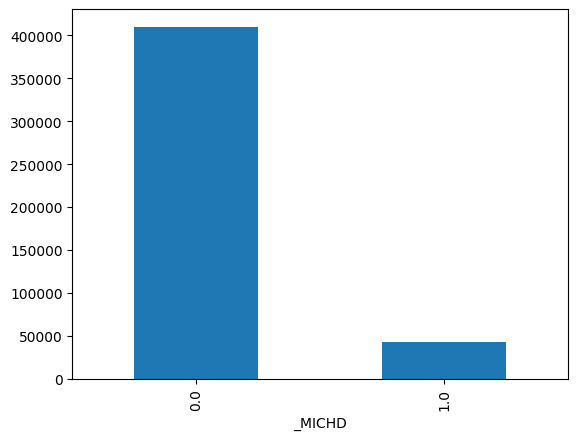

In [47]:
df['_MICHD'].value_counts().plot(kind='bar')   # visual check

### Distributions \(Spot Skew \+ Normality\)

### Boxplots — Outlier Detector

### Correlation Heatmap — Relationship Detector 

### Categorical Count Plots

### Pairplot — Full Picture

## Relationship and Group Analysis

## Outlier Detection and Treatment

## Data Preprocessing 

### Encode Categorical Variables

# 

### Feature Scaling

### Feature Engineering

### Train and Test Split

## Model Development and Evaluation 

### Logistic Regression

### Random Forest

### XGBoost

## Model Selection

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=88479c56-07bc-4e04-92b4-d8345dc226f4' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>